In [55]:
import numpy as np
import functools
import pickle
import time
import torch
from matplotlib import pyplot as pp
from scipy.stats import gaussian_kde

In [56]:
with open('/Users/anshgrover/AIDA3/PINN-tutorial/data/massdamper_data.pkl', 'rb') as f:
    data = pickle.load(f)

# full ground truth — we will subsample from this
gt = data['data_groundtruth']['model: No external force']
t_full = gt['t']
x_full = gt['x']

print(f"Full ground truth: {len(t_full)} points over {t_full[-1]:.1f}s")

# true parameters
m_true      = 2.0
c_true      = 0.3
k_true      = 0.2
delta_true  = c_true / (2 * m_true)
omega0_true = np.sqrt(k_true / m_true)

print(f"true delta  = {delta_true:.4f}")
print(f"true omega0 = {omega0_true:.4f}")

Full ground truth: 600 points over 60.0s
true delta  = 0.0750
true omega0 = 0.3162


In [57]:
def msd(t, y, delta, omega0):
    if not torch.is_tensor(y):
        y = torch.tensor(y, dtype=torch.float64)
    x, v = y[0], y[1]
    return torch.stack([v, -2*delta*v - omega0**2*x])

def rk4_integrate(f, t_eval, y0, m_sub):
    if not torch.is_tensor(y0):
        y0 = torch.tensor(y0, dtype=torch.float64)
    if not torch.is_tensor(t_eval):
        t_eval = torch.tensor(t_eval, dtype=torch.float64)
    Y = [y0]
    y = y0
    for i in range(1, len(t_eval)):
        dt = (t_eval[i] - t_eval[i-1]).item()
        h  = dt / m_sub
        yi = y
        ti = t_eval[i-1].item()
        for _ in range(m_sub):
            k1 = f(ti,       yi            )
            k2 = f(ti + h/2, yi + h/2 * k1)
            k3 = f(ti + h/2, yi + h/2 * k2)
            k4 = f(ti + h,   yi + h   * k3)
            yi = yi + (h/6) * (k1 + 2*k2 + 2*k3 + k4)
            ti += h
        y = yi
        Y.append(y)
    return torch.stack(Y)

def compute_gn(x_pred, y_obs):
    if not torch.is_tensor(x_pred):
        x_pred = torch.tensor(x_pred, dtype=torch.float64)
    if not torch.is_tensor(y_obs):
        y_obs  = torch.tensor(y_obs,  dtype=torch.float64)
    return torch.mean((y_obs - x_pred)**2)

def compute_m_sub(n, h):
    K              = 4
    theorem2_bound = n ** (-5 / (2 * K))
    return int(np.ceil(float(h) / theorem2_bound))

In [58]:
def find_x1hat_torch(delta, omega0, t_obs, y_obs, mu_x1, c, n, m_sub):
    x1 = torch.tensor([mu_x1], requires_grad=True, dtype=torch.float64)
    optimizer = torch.optim.LBFGS([x1], lr=1.0, max_iter=100)

    def closure():
        optimizer.zero_grad()
        f    = functools.partial(msd, delta=delta, omega0=omega0)
        Y    = rk4_integrate(f, t_obs,
                   torch.stack([x1[0], torch.tensor(0.0, dtype=torch.float64)]),
                   m_sub)
        gn   = compute_gn(Y[:, 0], y_obs)
        loss = n * gn + (x1[0] - mu_x1)**2 / c
        loss.backward()
        return loss

    optimizer.step(closure)
    return x1[0].detach()

def compute_gn_dd_autograd(x1_val, delta, omega0, t_obs, y_obs, n, m_sub):
    x1  = torch.tensor(x1_val, requires_grad=True, dtype=torch.float64)
    y0  = torch.stack([x1, torch.tensor(0.0, dtype=torch.float64)])
    f   = lambda t, y: msd(t, y, delta, omega0)
    Y   = rk4_integrate(f, t_obs, y0, m_sub)
    gn  = compute_gn(Y[:, 0], y_obs)
    dgn = torch.autograd.grad(gn, x1, create_graph=True)[0]
    return torch.autograd.grad(dgn, x1)[0].item()

def lap_posterior_u(theta, t_obs, y_obs, n, p, mu_x1, c, a, b, m_sub):
    delta  = theta[0]
    omega0 = theta[1]

    x1_hat = find_x1hat_torch(delta, omega0, t_obs, y_obs, mu_x1, c, n, m_sub)

    f      = functools.partial(msd, delta=delta, omega0=omega0)
    Y      = rk4_integrate(f, t_obs,
                 [x1_hat.item(), 0.0], m_sub)
    gn     = compute_gn(Y[:, 0], y_obs)
    u      = n * gn + (x1_hat - mu_x1)**2 / c

    if u <= 0:
        return float(-torch.inf), float(-torch.inf)

    gn_dd = compute_gn_dd_autograd(
                x1_hat.item(), delta, omega0, t_obs, y_obs, n, m_sub)
    H     = n * gn_dd + 2.0 / c
    if H <= 0:
        return float(-torch.inf), float(-torch.inf)

    v      = np.log(float(H))
    log_pi = -(n * p / 2 + a) * np.log(float(u) / 2 + b) - 0.5 * v

    return float(log_pi), float(u)

def lap_posterior(theta, t_obs, y_obs, n, p, mu_x1, c, a, b, m_sub):
    lp, _ = lap_posterior_u(theta, t_obs, y_obs, n, p, mu_x1, c, a, b, m_sub)
    return torch.tensor(lp, dtype=torch.float64)


In [74]:
from joblib import Parallel, delayed
import torch

def evaluate_grid_point(i, j, z_ij, theta0_np, A_np,
                         t_obs_np, y_obs_np, n, p, 
                         mu_x1, c, a, b, m_sub):
    """
    Standalone function — no global state, safe for multiprocessing.
    Reconstructs all tensors locally in each worker.
    """
    import torch
    import numpy as np
    import functools

    # Reconstruct tensors locally
    t_obs  = torch.tensor(t_obs_np,  dtype=torch.float64)
    y_obs  = torch.tensor(y_obs_np,  dtype=torch.float64)
    theta0 = torch.tensor(theta0_np, dtype=torch.float64)

    def msd(t, y, delta, omega0):
        if not torch.is_tensor(y):
            y = torch.tensor(y, dtype=torch.float64)
        x, v = y[0], y[1]
        return torch.stack([v, -2*delta*v - omega0**2*x])

    def rk4_integrate(f, t_eval, y0, m_sub):
        if not torch.is_tensor(y0):
            y0 = torch.tensor(y0, dtype=torch.float64)
        Y = [y0]
        y = y0
        for i in range(1, len(t_eval)):
            dt = (t_eval[i] - t_eval[i-1]).item()
            h  = dt / m_sub
            yi = y
            ti = t_eval[i-1].item()
            for _ in range(m_sub):
                k1 = f(ti,       yi            )
                k2 = f(ti + h/2, yi + h/2 * k1)
                k3 = f(ti + h/2, yi + h/2 * k2)
                k4 = f(ti + h,   yi + h   * k3)
                yi = yi + (h/6) * (k1 + 2*k2 + 2*k3 + k4)
                ti += h
            y = yi
            Y.append(y)
        return torch.stack(Y)

    def compute_gn(x_pred, y_obs):
        return torch.mean((y_obs - x_pred)**2)

    def compute_gn_dd_autograd(x1_val, theta):
        delta, omega0 = theta
        x1  = torch.tensor(x1_val, requires_grad=True, dtype=torch.float64)
        y0  = torch.stack([x1, torch.tensor(0.0, dtype=torch.float64)])
        f   = lambda t, y: msd(t, y, delta, omega0)
        Y   = rk4_integrate(f, t_obs, y0, m_sub)
        gn  = compute_gn(Y[:, 0], y_obs)
        dgn = torch.autograd.grad(gn, x1, create_graph=True)[0]
        return torch.autograd.grad(dgn, x1)[0].item()

    def find_x1hat(theta):
        delta, omega0 = theta[0], theta[1]
        x1 = torch.tensor([mu_x1], requires_grad=True, dtype=torch.float64)
        optimizer = torch.optim.LBFGS([x1], lr=1.0, max_iter=100)
        def closure():
            optimizer.zero_grad()
            f   = functools.partial(msd, delta=delta, omega0=omega0)
            Y   = rk4_integrate(f, t_obs,
                    torch.stack([x1[0], torch.tensor(0.0, dtype=torch.float64)]),
                    m_sub)
            gn  = compute_gn(Y[:, 0], y_obs)
            loss = n * gn + (x1[0] - mu_x1)**2 / c
            loss.backward()
            return loss
        optimizer.step(closure)
        return x1[0]

    # Evaluate grid point
    theta_ij = theta0 + torch.tensor(A_np @ z_ij, dtype=torch.float64)
    delta    = theta_ij[0]
    omega0   = theta_ij[1]
    theta_t  = (delta, omega0)

    x1_hat = find_x1hat(theta_ij).detach()

    f      = functools.partial(msd, delta=delta, omega0=omega0)
    Y      = rk4_integrate(f, t_obs, [x1_hat.item(), 0.0], m_sub)
    x_pred = Y[:, 0]
    gn     = compute_gn(x_pred, y_obs)
    u      = n * gn + (x1_hat - mu_x1)**2 / c

    if u <= 0:
        return i, j, float(-torch.inf), float(-torch.inf)

    gn_dd = compute_gn_dd_autograd(x1_hat.item(), theta_t)
    H     = n * gn_dd + 2.0 / c
    if H <= 0:
        return i, j, float(-torch.inf), float(-torch.inf)

    v      = np.log(H)
    log_pi = -(n * p / 2 + a) * np.log(float(u) / 2 + b) - 0.5 * v

    return i, j, float(log_pi), float(u)


def LAP_parallel(t_obs_np, y_obs_np, theta0_np, n, p, mu_x1, c, a, b, m_sub, M2=5, n_jobs=-1):

    t_obs_t = torch.tensor(t_obs_np, dtype=torch.float64)
    y_obs_t = torch.tensor(y_obs_np, dtype=torch.float64)
    theta0  = torch.tensor(theta0_np, dtype=torch.float64)

    def lap_post(theta):
        delta  = theta[0]
        omega0 = theta[1]

        x1_hat = find_x1hat_torch(delta, omega0, t_obs_t, y_obs_t, mu_x1, c, n, m_sub)

        f      = functools.partial(msd, delta=delta, omega0=omega0)
        Y      = rk4_integrate(f, t_obs_t,
                    torch.stack([x1_hat, torch.tensor(0.0, dtype=torch.float64)]),
                    m_sub)
        gn     = compute_gn(Y[:, 0], y_obs_t)
        u      = n * gn + (x1_hat - mu_x1)**2 / c

        gn_dd  = compute_gn_dd_autograd(
                    x1_hat.item(), delta, omega0, t_obs_t, y_obs_t, n, m_sub)
        H_val  = n * gn_dd + 2.0 / c
        v      = torch.log(torch.tensor(H_val, dtype=torch.float64))

        log_pi = -(n * p / 2 + a) * torch.log(u / 2 + b) - 0.5 * v
        return log_pi

    # Hessian and reparametrisation
    H_mat    = torch.autograd.functional.hessian(lap_post, theta0)
    neg_H    = -H_mat.numpy()
    evals, U = np.linalg.eigh(neg_H)
    print(f"Eigenvalues before fix: {evals}")
    min_pos  = evals[evals > 0].min() if (evals > 0).any() else 1e-4
    evals    = np.where(evals <= 0, min_pos, evals)
    A        = np.matmul(U, np.diag(evals ** -0.5))
    print(f"A matrix:\n{A}")

    # Coarse scan
    M1   = 3
    z_1d = np.linspace(-4, 4, 2*M1 + 1)

    # First pass — find peak log posterior
    peak_lp = -np.inf
    for dim in range(2):
        for z_val in z_1d:
            z          = np.zeros(2)
            z[dim]     = z_val
            theta_test = theta0 + torch.tensor(A @ z, dtype=torch.float64)
            lp         = float(lap_posterior(
                theta_test, t_obs_t, y_obs_t, n, p, mu_x1, c, a, b, m_sub))
            print(f"  dim={dim} z={z_val:+.2f} "
                  f"theta=({float(theta_test[0]):.4f},{float(theta_test[1]):.4f}) "
                  f"lp={lp:.2f}")
            if lp > peak_lp:
                peak_lp = lp

    eta_rel = peak_lp - 11.5
    print(f"Peak log posterior: {peak_lp:.2f}  threshold: {eta_rel:.2f}")

    # Second pass — keep points within 11.5 of peak
    A_bounds, B_bounds = [], []
    for dim in range(2):
        active = []
        for z_val in z_1d:
            z          = np.zeros(2)
            z[dim]     = z_val
            theta_test = theta0 + torch.tensor(A @ z, dtype=torch.float64)
            lp         = float(lap_posterior(
                theta_test, t_obs_t, y_obs_t, n, p, mu_x1, c, a, b, m_sub))
            if lp > eta_rel:
                active.append(z_val)
        A_bounds.append(min(active) if active else -4)
        B_bounds.append(max(active) if active else  4)

    print(f"Coarse scan bounds: z[0]=[{A_bounds[0]:.2f},{B_bounds[0]:.2f}]  "
          f"z[1]=[{A_bounds[1]:.2f},{B_bounds[1]:.2f}]")

    # Fine grid
    z0_1d  = np.linspace(A_bounds[0], B_bounds[0], 2*M2 + 1)
    z1_1d  = np.linspace(A_bounds[1], B_bounds[1], 2*M2 + 1)
    Z0, Z1 = np.meshgrid(z0_1d, z1_1d)

    # Build grid args
    grid_args = [
        (i, j, np.array([Z0[i,j], Z1[i,j]]),
         theta0_np, A,
         t_obs_np, y_obs_np,
         n, p, mu_x1, c, a, b, m_sub)
        for i in range(Z0.shape[0])
        for j in range(Z0.shape[1])
    ]

    print(f"Evaluating {len(grid_args)} grid points on {n_jobs} cores...")
    t_start = time.time()

    results = Parallel(n_jobs=n_jobs, backend='loky', verbose=0)(
        delayed(evaluate_grid_point)(*args) for args in grid_args
    )

    print(f"Grid evaluation time: {time.time() - t_start:.1f}s")

    # Fill grids
    log_pi = np.zeros_like(Z0)
    u_grid = np.zeros_like(Z0)
    for i, j, lp, u in results:
        log_pi[i, j] = lp
        u_grid[i, j] = u

    # Normalize and sample
    log_pi_shifted = log_pi - np.max(log_pi)
    pi             = np.exp(log_pi_shifted)
    pi            /= pi.sum()

    N_samples    = 1000
    flat_idx     = np.random.choice(len(pi.flatten()), size=N_samples, p=pi.flatten())
    i_idx, j_idx = np.unravel_index(flat_idx, pi.shape)

    theta_samples = np.array([
        theta0_np + A @ np.array([Z0[i,j], Z1[i,j]])
        for i, j in zip(i_idx, j_idx)
    ])

    u_flat       = u_grid.flatten()[flat_idx]
    tau2_samples = np.array([
        np.random.gamma(shape=n*p/2+a, scale=1.0/(u_flat[k]/2+b))
        for k in range(N_samples)
    ])

    return theta_samples, tau2_samples

In [67]:
def find_theta0_sweep(t_obs_np, y_obs_np, n, p, mu_x1, c, a, b, m_sub):
    t_obs_t = torch.tensor(t_obs_np, dtype=torch.float64)
    y_obs_t = torch.tensor(y_obs_np, dtype=torch.float64)

    def coarse_to_fine(delta_range, omega0_range, n_points=5):
        best_lp    = -np.inf
        best_theta = None
        for d in np.linspace(*delta_range, n_points):
            for w in np.linspace(*omega0_range, n_points):
                theta = torch.tensor([d, w], dtype=torch.float64)
                lp, _ = lap_posterior_u(
                    theta, t_obs_t, y_obs_t, n, p, mu_x1, c, a, b, m_sub)
                if lp > best_lp:
                    best_lp    = lp
                    best_theta = np.array([d, w])
        return best_theta, best_lp

    best1, _ = coarse_to_fine((0.01, 0.2), (0.1, 0.6), n_points=5)
    best2, _ = coarse_to_fine(
        (best1[0]-0.05, best1[0]+0.05),
        (best1[1]-0.10, best1[1]+0.10), n_points=5)
    best3, _ = coarse_to_fine(
        (best2[0]-0.01, best2[0]+0.01),
        (best2[1]-0.02, best2[1]+0.02), n_points=5)

    print(f"theta0: delta={best3[0]:.4f}  omega0={best3[1]:.4f}")
    return best3

In [60]:
def run_LAP(t_obs, y_obs, theta0_np, n, p, mu_x1, c, a, b, m_sub, M2=10):

    M2 = 5

    t_obs_t = torch.tensor(t_obs, dtype=torch.float64)
    y_obs_t = torch.tensor(y_obs, dtype=torch.float64)
    theta0  = torch.tensor(theta0_np, dtype=torch.float64)

    def lap_post(theta):
        delta  = theta[0]
        omega0 = theta[1]

        x1_hat = find_x1hat_torch(delta, omega0, t_obs_t, y_obs_t, mu_x1, c, n, m_sub)

        f      = functools.partial(msd, delta=delta, omega0=omega0)
        Y      = rk4_integrate(f, t_obs_t,
                    torch.stack([x1_hat, torch.tensor(0.0, dtype=torch.float64)]),
                    m_sub)
        gn     = compute_gn(Y[:, 0], y_obs_t)
        u      = n * gn + (x1_hat - mu_x1)**2 / c

        gn_dd  = compute_gn_dd_autograd(
                    x1_hat.item(), delta, omega0, t_obs_t, y_obs_t, n, m_sub)
        H_val  = n * gn_dd + 2.0 / c
        v      = torch.log(torch.tensor(H_val, dtype=torch.float64))

        log_pi = -(n * p / 2 + a) * torch.log(u / 2 + b) - 0.5 * v
        return log_pi

    # Hessian and reparametrisation
    H_mat      = torch.autograd.functional.hessian(lap_post, theta0)
    neg_H      = -H_mat.numpy()
    evals, U   = np.linalg.eigh(neg_H)
    min_pos    = evals[evals > 0].min() if (evals > 0).any() else 1e-8
    evals      = np.where(evals <= 0, min_pos, evals)
    A          = np.matmul(U, np.diag(evals ** -0.5))

    # Coarse scan
    M1, eta = 3, 1e-5
    z_1d    = np.linspace(-4, 4, 2*M1 + 1)
    A_bounds, B_bounds = [], []
    for dim in range(2):
        active = []
        for z_val in z_1d:
            z          = np.zeros(2)
            z[dim]     = z_val
            theta_test = theta0 + torch.tensor(A @ z, dtype=torch.float64)
            lp, _      = lap_posterior_u(
                theta_test, t_obs_t, y_obs_t, n, p, mu_x1, c, a, b, m_sub)
            if lp > np.log(eta):
                active.append(z_val)
        A_bounds.append(min(active) if active else -4)
        B_bounds.append(max(active) if active else  4)

    # Fine grid
    z0_1d = np.linspace(A_bounds[0], B_bounds[0], 2*M2 + 1)
    z1_1d = np.linspace(A_bounds[1], B_bounds[1], 2*M2 + 1)
    Z0, Z1 = np.meshgrid(z0_1d, z1_1d)
    log_pi = np.zeros_like(Z0)
    u_grid = np.zeros_like(Z0)

    for i in range(Z0.shape[0]):
        for j in range(Z0.shape[1]):
            z        = np.array([Z0[i,j], Z1[i,j]])
            theta_ij = theta0 + torch.tensor(A @ z, dtype=torch.float64)
            lp, u    = lap_posterior_u(
                theta_ij, t_obs_t, y_obs_t, n, p, mu_x1, c, a, b, m_sub)
            log_pi[i,j] = lp
            u_grid[i,j] = u

    # Normalize and sample
    log_pi_shifted = log_pi - np.max(log_pi)
    pi             = np.exp(log_pi_shifted)
    pi            /= pi.sum()

    N_samples  = 1000
    flat_idx   = np.random.choice(len(pi.flatten()), size=N_samples, p=pi.flatten())
    i_idx, j_idx = np.unravel_index(flat_idx, pi.shape)

    theta_samples = np.array([
        (theta0 + torch.tensor(A @ np.array([Z0[i,j], Z1[i,j]]),
         dtype=torch.float64)).numpy()
        for i, j in zip(i_idx, j_idx)
    ])

    u_flat       = u_grid.flatten()[flat_idx]
    tau2_samples = np.array([
        np.random.gamma(shape=n*p/2+a, scale=1.0/(u_flat[k]/2+b))
        for k in range(N_samples)
    ])

    return theta_samples, tau2_samples

In [61]:
def run_MAP_LAP(t_obs, y_obs, theta_prior, D, n, mu_x1, c, R, m_sub):

    t_obs_t = torch.tensor(t_obs, dtype=torch.float64)
    y_obs_t = torch.tensor(y_obs, dtype=torch.float64)

    def J(z):
        theta  = theta_prior + D @ z
        delta  = theta[0].detach()
        omega0 = theta[1].detach()

        with torch.no_grad():
            x1_hat_val = find_x1hat_torch(
                delta, omega0, t_obs_t, y_obs_t, mu_x1, c, n, m_sub).item()

        f      = functools.partial(msd, delta=theta[0], omega0=theta[1])
        Y      = rk4_integrate(f, t_obs_t,
                     torch.stack([
                         torch.tensor(x1_hat_val, dtype=torch.float64),
                         torch.tensor(0.0,        dtype=torch.float64)
                     ]), m_sub)
        J_data  = (1.0 / (2 * n * R)) * torch.sum((y_obs_t - Y[:, 0]) ** 2)
        J_prior = 0.5 * torch.dot(z, z)
        return J_data + J_prior

    # MAP optimization
    z = torch.zeros(2, dtype=torch.float64, requires_grad=True)
    optimizer = torch.optim.LBFGS([z], lr=1.0, max_iter=500,
                                   tolerance_grad=1e-9,
                                   tolerance_change=1e-12,
                                   line_search_fn='strong_wolfe')

    def closure():
        optimizer.zero_grad()
        loss = J(z)
        loss.backward()
        return loss

    optimizer.step(closure)
    z_map     = z.detach().clone()
    theta_map = (theta_prior + D @ z_map).detach()

    # Hessian
    H           = torch.autograd.functional.hessian(J, z_map)
    Sigma_z     = torch.linalg.inv(H)
    Sigma_theta = D @ Sigma_z @ D.T

    # Sample
    dist          = torch.distributions.MultivariateNormal(
                        theta_map.float(), Sigma_theta.float())
    theta_samples = dist.sample((1000,)).double()
    valid         = (theta_samples[:, 0] > 0) & (theta_samples[:, 1] > 0)
    theta_samples = theta_samples[valid].numpy()

    return theta_samples, theta_map.numpy(), Sigma_theta.detach().numpy()

In [62]:
def compute_metrics(theta_samples, delta_true, omega0_true):
    d_mean  = np.mean(theta_samples[:, 0])
    w_mean  = np.mean(theta_samples[:, 1])
    d_ci    = np.percentile(theta_samples[:, 0], [2.5, 97.5])
    w_ci    = np.percentile(theta_samples[:, 1], [2.5, 97.5])
    return {
        'd_mean':    d_mean,
        'w_mean':    w_mean,
        'd_bias':    abs(d_mean - delta_true),
        'w_bias':    abs(w_mean - omega0_true),
        'd_ci':      d_ci,
        'w_ci':      w_ci,
        'd_width':   d_ci[1] - d_ci[0],
        'w_width':   w_ci[1] - w_ci[0],
        'd_cover':   d_ci[0] <= delta_true  <= d_ci[1],
        'w_cover':   w_ci[0] <= omega0_true <= w_ci[1],
    }

In [94]:
# Prior hyperparameters
a, b  = 0.1, 0.01
c     = 100.0
theta_prior = torch.tensor([0.10, 0.35], dtype=torch.float64)
D           = torch.diag(torch.tensor([0.20, 0.40], dtype=torch.float64))
n_obs       = 100

# Noise levels to sweep
sigma_values = [0.01, 0.05, 0.1, 0.2, 0.5]
data_dir    = '/Users/anshgrover/AIDA3/PINN-tutorial/data/'

sigma_files = {
    0.01: data_dir + 'data_sigma001.pkl',
    0.05: data_dir + 'data_sigma005.pkl',
    0.1:  data_dir + 'data_sigma010.pkl',
    0.2:  data_dir + 'data_sigma020.pkl',
    0.5:  data_dir + 'data_sigma050.pkl',
}

lap_results     = []
map_lap_results = []

for sigma in sigma_values:
    print(f"\n{'='*50}")
    print(f"σ = {sigma}")
    print('='*50)

    R = sigma ** 2

    # Load pre-generated data for this sigma
    with open(sigma_files[sigma], 'rb') as f:
        d = pickle.load(f)

    obs     = d['data_sampled_random_with_noise']['No external force']['sparsity 1.667Hz']
    t_obs   = obs['t']
    y_obs   = obs['x']
    mu_x1   = y_obs[0]
    h       = t_obs[1] - t_obs[0]
    m_sub   = compute_m_sub(n_obs, h)

    print(f"t_obs spacing: min={np.diff(t_obs).min():.4f}  max={np.diff(t_obs).max():.4f}")
    print(f"m_sub = {m_sub}")

    # ── Find good theta0 ──────────────────────────────
    print("Finding theta0...")
    theta0_np = find_theta0_sweep(t_obs, y_obs, n_obs, 1, mu_x1, c, a, b, m_sub)

    # ── LAP ──────────────────────────────────────────
    print("Running LAP...")
    t_start = time.time()
    try:
        lap_samples, _ = LAP_parallel(
            t_obs, y_obs, theta0_np,
            n_obs, 1, mu_x1, c, a, b, m_sub, M2=5, n_jobs=-1
        )
        lap_metrics = compute_metrics(lap_samples, delta_true, omega0_true)
        lap_metrics['runtime'] = time.time() - t_start
        lap_metrics['sigma']   = sigma
        lap_metrics['status']  = 'ok'
    except Exception as e:
        print(f"LAP failed: {e}")
        lap_metrics = {'sigma': sigma, 'status': 'failed'}
    lap_results.append(lap_metrics)

    # ── MAP-LAP ───────────────────────────────────────
    print("Running MAP-LAP...")
    t_start = time.time()
    try:
        ml_samples, ml_theta_map, _ = run_MAP_LAP(
            t_obs, y_obs, theta_prior, D,
            n_obs, mu_x1, c, R, m_sub
        )
        ml_metrics = compute_metrics(ml_samples, delta_true, omega0_true)
        ml_metrics['runtime'] = time.time() - t_start
        ml_metrics['sigma']   = sigma
        ml_metrics['status']  = 'ok'
    except Exception as e:
        print(f"MAP-LAP failed: {e}")
        ml_metrics = {'sigma': sigma, 'status': 'failed'}
    map_lap_results.append(ml_metrics)

    # Print summary
    if lap_metrics['status'] == 'ok':
        print(f"LAP     δ: est={lap_metrics['d_mean']:.4f}  "
              f"bias={lap_metrics['d_bias']:.4f}  "
              f"CI width={lap_metrics['d_width']:.4f}  "
              f"cover={lap_metrics['d_cover']}  "
              f"t={lap_metrics['runtime']:.1f}s")
    if ml_metrics['status'] == 'ok':
        print(f"MAP-LAP δ: est={ml_metrics['d_mean']:.4f}  "
              f"bias={ml_metrics['d_bias']:.4f}  "
              f"CI width={ml_metrics['d_width']:.4f}  "
              f"cover={ml_metrics['d_cover']}  "
              f"t={ml_metrics['runtime']:.1f}s")

print("\nNoise sweep complete.")


σ = 0.01
t_obs spacing: min=0.6010  max=0.7012
m_sub = 11
Finding theta0...
theta0: delta=0.0800  omega0=0.3200
Running LAP...
Eigenvalues before fix: [ 444635.41569221 2316544.3844714 ]
A matrix:
[[-0.00108146 -0.00045518]
 [-0.00103898  0.0004738 ]]
  dim=0 z=-4.00 theta=(0.0843,0.3242) lp=176.35
  dim=0 z=-2.67 theta=(0.0829,0.3228) lp=184.34
  dim=0 z=-1.33 theta=(0.0814,0.3214) lp=192.25
  dim=0 z=+0.00 theta=(0.0800,0.3200) lp=199.61
  dim=0 z=+1.33 theta=(0.0786,0.3186) lp=205.77
  dim=0 z=+2.67 theta=(0.0771,0.3172) lp=209.87
  dim=0 z=+4.00 theta=(0.0757,0.3158) lp=211.11
  dim=1 z=-4.00 theta=(0.0818,0.3181) lp=194.11
  dim=1 z=-2.67 theta=(0.0812,0.3187) lp=197.46
  dim=1 z=-1.33 theta=(0.0806,0.3194) lp=199.36
  dim=1 z=+0.00 theta=(0.0800,0.3200) lp=199.61
  dim=1 z=+1.33 theta=(0.0794,0.3206) lp=198.16
  dim=1 z=+2.67 theta=(0.0788,0.3213) lp=195.13
  dim=1 z=+4.00 theta=(0.0782,0.3219) lp=190.76
Peak log posterior: 211.11  threshold: 199.61
Coarse scan bounds: z[0]=[0.0

In [36]:
from joblib import cpu_count
print(f"Available cores: {cpu_count()}")

Available cores: 8


In [78]:
# Find good theta0 first
theta0_np = find_theta0_sweep(t_test, y_test, n_obs, 1, mu_x1, 100.0, 0.1, 0.01, m_sub)

lap_samples, _ = LAP_parallel(
    t_test, y_test, theta0_np,
    n_obs, 1, mu_x1, 100.0, 0.1, 0.01, m_sub,
    M2=5, n_jobs=-1
)

theta0: delta=0.0750  omega0=0.3200
Eigenvalues before fix: [ 46336.32963855 128943.36202824]
A matrix:
[[-0.00325011 -0.00198983]
 [-0.00331936  0.00194831]]
  dim=0 z=-4.00 theta=(0.0880,0.3333) lp=39.33
  dim=0 z=-2.67 theta=(0.0837,0.3289) lp=41.86
  dim=0 z=-1.33 theta=(0.0793,0.3244) lp=43.64
  dim=0 z=+0.00 theta=(0.0750,0.3200) lp=44.36
  dim=0 z=+1.33 theta=(0.0707,0.3156) lp=43.69
  dim=0 z=+2.67 theta=(0.0663,0.3111) lp=41.37
  dim=0 z=+4.00 theta=(0.0620,0.3067) lp=37.31
  dim=1 z=-4.00 theta=(0.0830,0.3122) lp=38.96
  dim=1 z=-2.67 theta=(0.0803,0.3148) lp=42.09
  dim=1 z=-1.33 theta=(0.0777,0.3174) lp=43.99
  dim=1 z=+0.00 theta=(0.0750,0.3200) lp=44.36
  dim=1 z=+1.33 theta=(0.0723,0.3226) lp=43.06
  dim=1 z=+2.67 theta=(0.0697,0.3252) lp=40.12
  dim=1 z=+4.00 theta=(0.0670,0.3278) lp=35.72
Peak log posterior: 44.36  threshold: 32.86
Coarse scan bounds: z[0]=[-4.00,4.00]  z[1]=[-4.00,4.00]
Evaluating 121 grid points on -1 cores...
Grid evaluation time: 41.9s


In [75]:
lap_samples, _ = LAP_parallel(
    t_test, y_test, theta0_np,
    n_obs, 1, mu_x1, 100.0, 0.1, 0.01, m_sub,
    M2=5, n_jobs=-1
)

Eigenvalues before fix: [ 45899.54073212 131541.99130835]
A matrix:
[[-0.00310112 -0.00206069]
 [-0.00348852  0.00183186]]
  dim=0 z=-4.00 theta=(0.0857,0.3362) lp=37.48
  dim=0 z=-2.67 theta=(0.0816,0.3315) lp=40.34
  dim=0 z=-1.33 theta=(0.0775,0.3269) lp=42.47
  dim=0 z=+0.00 theta=(0.0733,0.3222) lp=43.55
  dim=0 z=+1.33 theta=(0.0692,0.3176) lp=43.21
  dim=0 z=+2.67 theta=(0.0651,0.3129) lp=41.19
  dim=0 z=+4.00 theta=(0.0609,0.3083) lp=37.35
  dim=1 z=-4.00 theta=(0.0816,0.3149) lp=41.53
  dim=1 z=-2.67 theta=(0.0788,0.3173) lp=43.68
  dim=1 z=-1.33 theta=(0.0761,0.3198) lp=44.41
  dim=1 z=+0.00 theta=(0.0733,0.3222) lp=43.55
  dim=1 z=+1.33 theta=(0.0706,0.3247) lp=41.06
  dim=1 z=+2.67 theta=(0.0678,0.3271) lp=37.10
  dim=1 z=+4.00 theta=(0.0651,0.3295) lp=31.90
Peak log posterior: 44.41  threshold: 32.91
Coarse scan bounds: z[0]=[-4.00,4.00]  z[1]=[-4.00,2.67]
Evaluating 121 grid points on -1 cores...
Grid evaluation time: 41.3s


In [77]:
print(lap_samples.shape)

(1000, 2)


In [79]:
print(f"δ  est={np.mean(lap_samples[:,0]):.4f}  true={delta_true:.4f}")
print(f"ω₀ est={np.mean(lap_samples[:,1]):.4f}  true={omega0_true:.4f}")
print(f"δ  CI={np.percentile(lap_samples[:,0],[2.5,97.5])}")
print(f"ω₀ CI={np.percentile(lap_samples[:,1],[2.5,97.5])}")

δ  est=0.0764  true=0.0750
ω₀ est=0.3196  true=0.3162
δ  CI=[0.06820797 0.08598398]
ω₀ CI=[0.31157172 0.32842828]


In [80]:
print(f"sigma_values = {sigma_values}")
print(f"n_obs = {n_obs}")
print(f"M2 = {M2}")  # should be 5

sigma_values = [0.01, 0.05, 0.1, 0.2, 0.5]
n_obs = 100


NameError: name 'M2' is not defined

In [82]:
print(f"t_full spacing: min={np.diff(t_full).min():.4f}  max={np.diff(t_full).max():.4f}")
print(f"t_obs spacing: min={np.diff(t_obs).min():.4f}  max={np.diff(t_obs).max():.4f}")

t_full spacing: min=0.1002  max=0.1002
t_obs spacing: min=0.6010  max=0.7012


In [86]:
gt = data['data_groundtruth']['model: No external force']
print(f"x_full sample: {gt['x'][:5]}")

# Compare with noisy version
noisy = data['data_sampled_random_with_noise']['No external force']['sparsity 1.667Hz']
print(f"x_noisy sample: {noisy['x'][:5]}")

x_full sample: [1.         0.99950087 0.9980138  0.99555499 0.99214156]
x_noisy sample: [1.03024497 0.91972945 0.93428314 0.78211975 0.60113655]


In [90]:
 # Generate noisy observations at this sigma
np.random.seed(42)
indices = np.round(np.linspace(0, len(t_full)-1, n_obs)).astype(int)
t_obs   = t_full[indices]
x_clean = x_full[indices]
y_obs   = x_clean + np.random.normal(0, sigma, size=n_obs)

mu_x1 = y_obs[0]
h     = t_obs[1] - t_obs[0]
m_sub = compute_m_sub(n_obs, h)


In [91]:
print(f"t_full spacing: min={np.diff(t_full).min():.4f}  max={np.diff(t_full).max():.4f}")
print(f"t_obs spacing: min={np.diff(t_obs).min():.4f}  max={np.diff(t_obs).max():.4f}")

t_full spacing: min=0.1002  max=0.1002
t_obs spacing: min=0.6010  max=0.7012


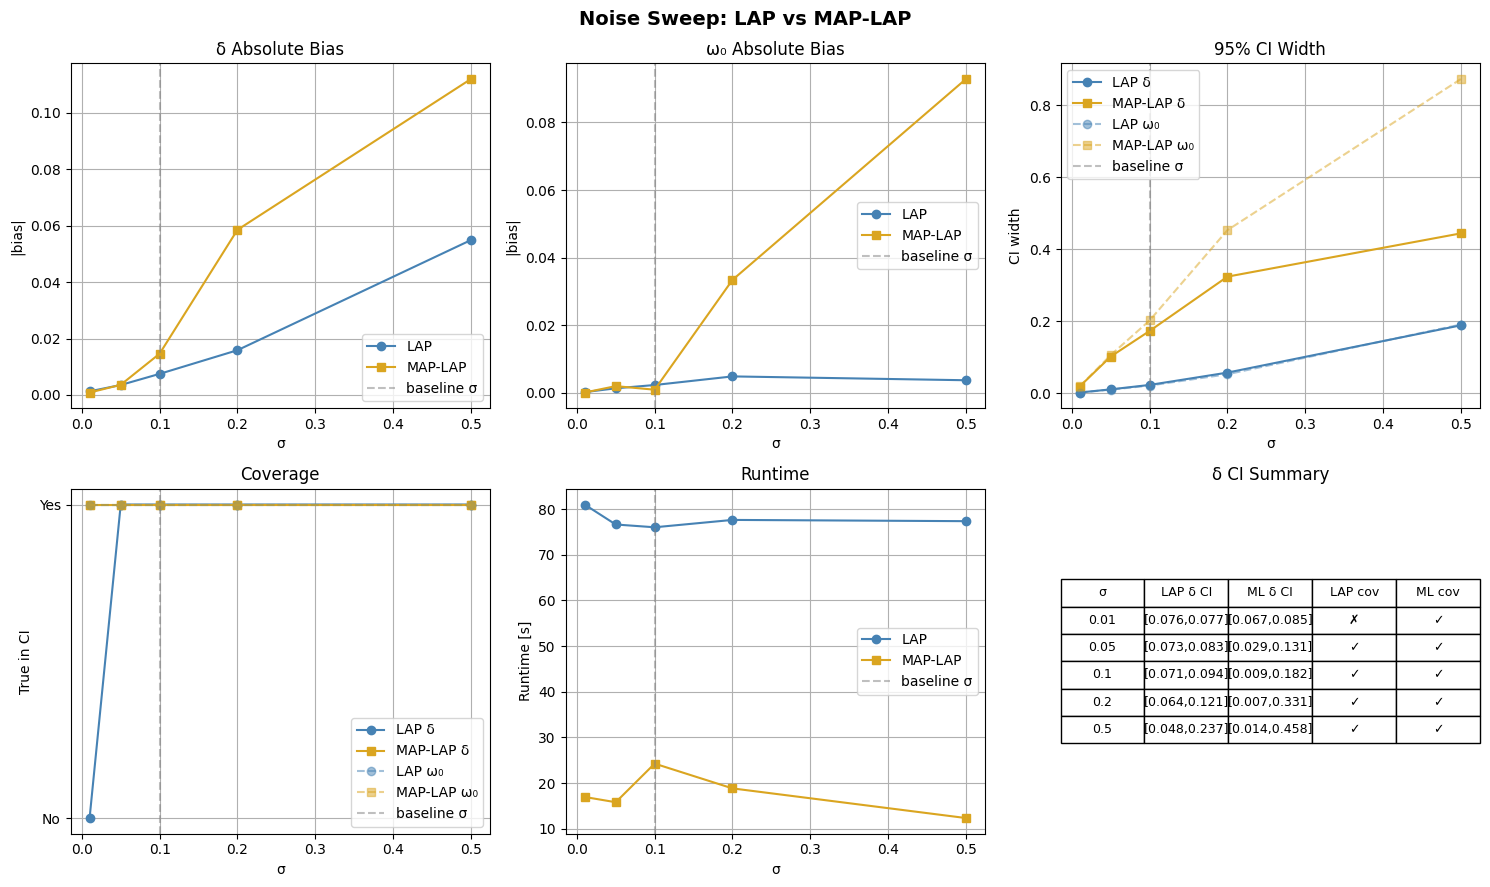

Saved: sweep_noise.png


In [95]:
import matplotlib.pyplot as pp
import numpy as np

# Extract results
sigma_vals = [r['sigma'] for r in lap_results if r['status'] == 'ok']

# LAP metrics
lap_d_bias   = [r['d_bias']  for r in lap_results if r['status'] == 'ok']
lap_w_bias   = [r['w_bias']  for r in lap_results if r['status'] == 'ok']
lap_d_width  = [r['d_width'] for r in lap_results if r['status'] == 'ok']
lap_w_width  = [r['w_width'] for r in lap_results if r['status'] == 'ok']
lap_d_cover  = [int(r['d_cover']) for r in lap_results if r['status'] == 'ok']
lap_w_cover  = [int(r['w_cover']) for r in lap_results if r['status'] == 'ok']
lap_rt       = [r['runtime'] for r in lap_results if r['status'] == 'ok']

# MAP-LAP metrics
ml_d_bias    = [r['d_bias']  for r in map_lap_results if r['status'] == 'ok']
ml_w_bias    = [r['w_bias']  for r in map_lap_results if r['status'] == 'ok']
ml_d_width   = [r['d_width'] for r in map_lap_results if r['status'] == 'ok']
ml_w_width   = [r['w_width'] for r in map_lap_results if r['status'] == 'ok']
ml_d_cover   = [int(r['d_cover']) for r in map_lap_results if r['status'] == 'ok']
ml_w_cover   = [int(r['w_cover']) for r in map_lap_results if r['status'] == 'ok']
ml_rt        = [r['runtime'] for r in map_lap_results if r['status'] == 'ok']

fig, axes = pp.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Noise Sweep: LAP vs MAP-LAP', fontsize=14, fontweight='bold')

# ── δ bias ──────────────────────────────────────────
axes[0,0].plot(sigma_vals, lap_d_bias, 'o-', color='steelblue', label='LAP')
axes[0,0].plot(sigma_vals, ml_d_bias,  's-', color='goldenrod', label='MAP-LAP')
axes[0,0].axvline(0.1, color='gray', linestyle='--', alpha=0.5, label='baseline σ')
axes[0,0].set_xlabel('σ'); axes[0,0].set_ylabel('|bias|')
axes[0,0].set_title('δ Absolute Bias')
axes[0,0].legend(); axes[0,0].grid(True)

# ── ω₀ bias ─────────────────────────────────────────
axes[0,1].plot(sigma_vals, lap_w_bias, 'o-', color='steelblue', label='LAP')
axes[0,1].plot(sigma_vals, ml_w_bias,  's-', color='goldenrod', label='MAP-LAP')
axes[0,1].axvline(0.1, color='gray', linestyle='--', alpha=0.5, label='baseline σ')
axes[0,1].set_xlabel('σ'); axes[0,1].set_ylabel('|bias|')
axes[0,1].set_title('ω₀ Absolute Bias')
axes[0,1].legend(); axes[0,1].grid(True)

# ── CI width ─────────────────────────────────────────
axes[0,2].plot(sigma_vals, lap_d_width, 'o-', color='steelblue', label='LAP δ')
axes[0,2].plot(sigma_vals, ml_d_width,  's-', color='goldenrod', label='MAP-LAP δ')
axes[0,2].plot(sigma_vals, lap_w_width, 'o--', color='steelblue', alpha=0.5, label='LAP ω₀')
axes[0,2].plot(sigma_vals, ml_w_width,  's--', color='goldenrod', alpha=0.5, label='MAP-LAP ω₀')
axes[0,2].axvline(0.1, color='gray', linestyle='--', alpha=0.5, label='baseline σ')
axes[0,2].set_xlabel('σ'); axes[0,2].set_ylabel('CI width')
axes[0,2].set_title('95% CI Width')
axes[0,2].legend(); axes[0,2].grid(True)

# ── Coverage δ ───────────────────────────────────────
axes[1,0].plot(sigma_vals, lap_d_cover, 'o-', color='steelblue', label='LAP δ')
axes[1,0].plot(sigma_vals, ml_d_cover,  's-', color='goldenrod', label='MAP-LAP δ')
axes[1,0].plot(sigma_vals, lap_w_cover, 'o--', color='steelblue', alpha=0.5, label='LAP ω₀')
axes[1,0].plot(sigma_vals, ml_w_cover,  's--', color='goldenrod', alpha=0.5, label='MAP-LAP ω₀')
axes[1,0].axvline(0.1, color='gray', linestyle='--', alpha=0.5, label='baseline σ')
axes[1,0].set_xlabel('σ'); axes[1,0].set_ylabel('True in CI')
axes[1,0].set_title('Coverage')
axes[1,0].set_yticks([0, 1]); axes[1,0].set_yticklabels(['No', 'Yes'])
axes[1,0].legend(); axes[1,0].grid(True)

# ── Runtime ──────────────────────────────────────────
axes[1,1].plot(sigma_vals, lap_rt, 'o-', color='steelblue', label='LAP')
axes[1,1].plot(sigma_vals, ml_rt,  's-', color='goldenrod', label='MAP-LAP')
axes[1,1].axvline(0.1, color='gray', linestyle='--', alpha=0.5, label='baseline σ')
axes[1,1].set_xlabel('σ'); axes[1,1].set_ylabel('Runtime [s]')
axes[1,1].set_title('Runtime')
axes[1,1].legend(); axes[1,1].grid(True)

# ── Summary table ────────────────────────────────────
axes[1,2].axis('off')
col_labels = ['σ', 'LAP δ CI', 'ML δ CI', 'LAP cov', 'ML cov']
rows = []
for i, sigma in enumerate(sigma_vals):
    lap_r = lap_results[i]
    ml_r  = map_lap_results[i]
    if lap_r['status'] == 'ok' and ml_r['status'] == 'ok':
        rows.append([
            f"{sigma}",
            f"[{lap_r['d_ci'][0]:.3f},{lap_r['d_ci'][1]:.3f}]",
            f"[{ml_r['d_ci'][0]:.3f},{ml_r['d_ci'][1]:.3f}]",
            '✓' if lap_r['d_cover'] else '✗',
            '✓' if ml_r['d_cover'] else '✗',
        ])
table = axes[1,2].table(
    cellText=rows, colLabels=col_labels,
    loc='center', cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.5)
axes[1,2].set_title('δ CI Summary')

pp.tight_layout()
pp.savefig('sweep_noise.png', dpi=200, bbox_inches='tight')
pp.show()
print("Saved: sweep_noise.png")

In [96]:
with open(data_dir + 'data_n10.pkl', 'rb') as f:
    d = pickle.load(f)
print(d['data_sampled_random_with_noise']['No external force'].keys())

dict_keys(['sparsity 0.167Hz'])


In [99]:
# Sparsity sweep
n_values = [10, 25, 50, 100, 200]
n_files  = {
    10:  data_dir + 'data_n10.pkl',
    25:  data_dir + 'data_n25.pkl',
    50:  data_dir + 'data_n50.pkl',
    100: data_dir + 'data_n100.pkl',
    200: data_dir + 'data_n200.pkl',
}

sparsity_keys = {
    10:  'sparsity 0.167Hz',
    25:  'sparsity 0.417Hz',
    50:  'sparsity 0.833Hz',
    100: 'sparsity 1.667Hz',
    200: 'sparsity 3.333Hz',
}

sigma     = 0.1   # baseline noise
R         = sigma ** 2

lap_results_n     = []
map_lap_results_n = []

for n_obs in n_values:
    print(f"\n{'='*50}")
    print(f"n = {n_obs}")
    print('='*50)

    # Load pre-generated data
    with open(n_files[n_obs], 'rb') as f:
        d = pickle.load(f)

    obs = d['data_sampled_random_with_noise']['No external force'][sparsity_keys[n_obs]]    
    t_obs = obs['t']
    y_obs = obs['x']
    mu_x1 = y_obs[0]
    h     = t_obs[1] - t_obs[0]
    m_sub = compute_m_sub(n_obs, h)

    print(f"n_obs={n_obs}  h={h:.4f}  m_sub={m_sub}")

    # Find good theta0
    print("Finding theta0...")
    theta0_np = find_theta0_sweep(t_obs, y_obs, n_obs, 1, mu_x1, c, a, b, m_sub)

    # LAP
    print("Running LAP...")
    t_start = time.time()
    try:
        lap_samples, _ = LAP_parallel(
            t_obs, y_obs, theta0_np,
            n_obs, 1, mu_x1, c, a, b, m_sub, M2=5, n_jobs=-1
        )
        lap_metrics = compute_metrics(lap_samples, delta_true, omega0_true)
        lap_metrics['runtime'] = time.time() - t_start
        lap_metrics['n_obs']   = n_obs
        lap_metrics['status']  = 'ok'
    except Exception as e:
        print(f"LAP failed: {e}")
        lap_metrics = {'n_obs': n_obs, 'status': 'failed'}
    lap_results_n.append(lap_metrics)

    # MAP-LAP
    print("Running MAP-LAP...")
    t_start = time.time()
    try:
        ml_samples, ml_theta_map, _ = run_MAP_LAP(
            t_obs, y_obs, theta_prior, D,
            n_obs, mu_x1, c, R, m_sub
        )
        ml_metrics = compute_metrics(ml_samples, delta_true, omega0_true)
        ml_metrics['runtime'] = time.time() - t_start
        ml_metrics['n_obs']   = n_obs
        ml_metrics['status']  = 'ok'
    except Exception as e:
        print(f"MAP-LAP failed: {e}")
        ml_metrics = {'n_obs': n_obs, 'status': 'failed'}
    map_lap_results_n.append(ml_metrics)

    # Print summary
    if lap_metrics['status'] == 'ok':
        print(f"LAP     δ: est={lap_metrics['d_mean']:.4f}  "
              f"bias={lap_metrics['d_bias']:.4f}  "
              f"CI width={lap_metrics['d_width']:.4f}  "
              f"cover={lap_metrics['d_cover']}  "
              f"t={lap_metrics['runtime']:.1f}s")
    if ml_metrics['status'] == 'ok':
        print(f"MAP-LAP δ: est={ml_metrics['d_mean']:.4f}  "
              f"bias={ml_metrics['d_bias']:.4f}  "
              f"CI width={ml_metrics['d_width']:.4f}  "
              f"cover={ml_metrics['d_cover']}  "
              f"t={ml_metrics['runtime']:.1f}s")

print("\nSparsity sweep complete.")


n = 10
n_obs=10  h=6.6110  m_sub=28
Finding theta0...
theta0: delta=0.0950  omega0=0.3400
Running LAP...
Eigenvalues before fix: [ 891.19842529 5006.22241816]
A matrix:
[[-0.02648848 -0.00865141]
 [-0.02050476  0.01117607]]
  dim=0 z=-4.00 theta=(0.2010,0.4220) lp=11.03
  dim=0 z=-2.67 theta=(0.1656,0.3947) lp=11.58
  dim=0 z=-1.33 theta=(0.1303,0.3673) lp=12.55
  dim=0 z=+0.00 theta=(0.0950,0.3400) lp=13.76
  dim=0 z=+1.33 theta=(0.0597,0.3127) lp=12.96
  dim=0 z=+2.67 theta=(0.0244,0.2853) lp=7.59
  dim=0 z=+4.00 theta=(-0.0110,0.2580) lp=1.22
  dim=1 z=-4.00 theta=(0.1296,0.2953) lp=9.84
  dim=1 z=-2.67 theta=(0.1181,0.3102) lp=11.41
  dim=1 z=-1.33 theta=(0.1065,0.3251) lp=12.97
  dim=1 z=+0.00 theta=(0.0950,0.3400) lp=13.76
  dim=1 z=+1.33 theta=(0.0835,0.3549) lp=12.94
  dim=1 z=+2.67 theta=(0.0719,0.3698) lp=10.97
  dim=1 z=+4.00 theta=(0.0604,0.3847) lp=8.82
Peak log posterior: 13.76  threshold: 2.26
Coarse scan bounds: z[0]=[-4.00,2.67]  z[1]=[-4.00,4.00]
Evaluating 121 grid 

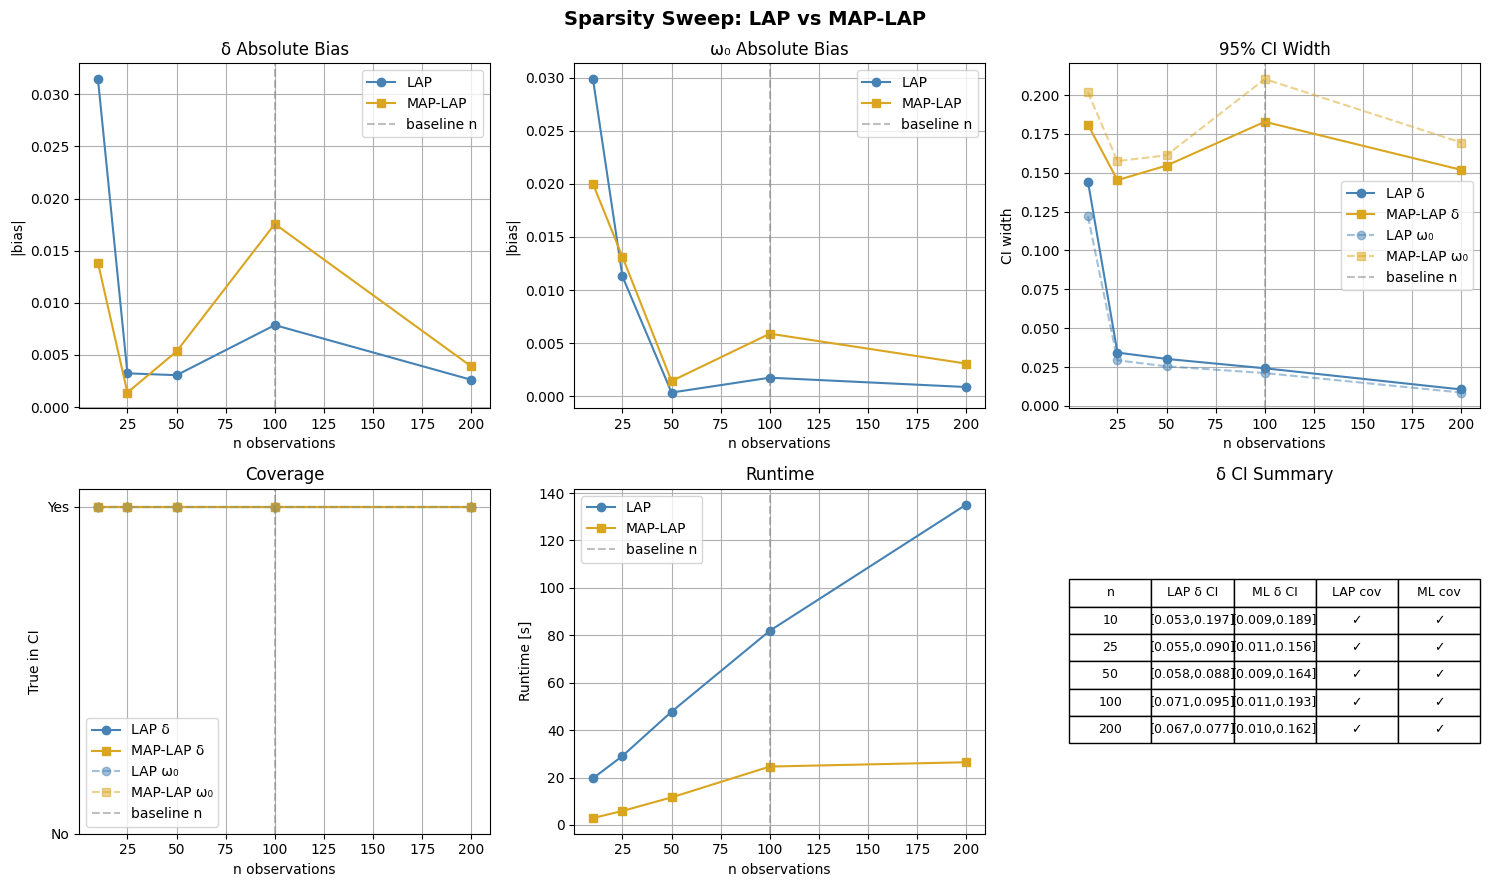

Saved: sweep_sparsity.png


In [100]:
# Extract sparsity sweep results
n_vals = [r['n_obs'] for r in lap_results_n if r['status'] == 'ok']

# LAP metrics
lap_d_bias_n  = [r['d_bias']  for r in lap_results_n if r['status'] == 'ok']
lap_w_bias_n  = [r['w_bias']  for r in lap_results_n if r['status'] == 'ok']
lap_d_width_n = [r['d_width'] for r in lap_results_n if r['status'] == 'ok']
lap_w_width_n = [r['w_width'] for r in lap_results_n if r['status'] == 'ok']
lap_d_cover_n = [int(r['d_cover']) for r in lap_results_n if r['status'] == 'ok']
lap_w_cover_n = [int(r['w_cover']) for r in lap_results_n if r['status'] == 'ok']
lap_rt_n      = [r['runtime'] for r in lap_results_n if r['status'] == 'ok']

# MAP-LAP metrics
ml_d_bias_n   = [r['d_bias']  for r in map_lap_results_n if r['status'] == 'ok']
ml_w_bias_n   = [r['w_bias']  for r in map_lap_results_n if r['status'] == 'ok']
ml_d_width_n  = [r['d_width'] for r in map_lap_results_n if r['status'] == 'ok']
ml_w_width_n  = [r['w_width'] for r in map_lap_results_n if r['status'] == 'ok']
ml_d_cover_n  = [int(r['d_cover']) for r in map_lap_results_n if r['status'] == 'ok']
ml_w_cover_n  = [int(r['w_cover']) for r in map_lap_results_n if r['status'] == 'ok']
ml_rt_n       = [r['runtime'] for r in map_lap_results_n if r['status'] == 'ok']

fig, axes = pp.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Sparsity Sweep: LAP vs MAP-LAP', fontsize=14, fontweight='bold')

# δ bias
axes[0,0].plot(n_vals, lap_d_bias_n, 'o-', color='steelblue', label='LAP')
axes[0,0].plot(n_vals, ml_d_bias_n,  's-', color='goldenrod', label='MAP-LAP')
axes[0,0].axvline(100, color='gray', linestyle='--', alpha=0.5, label='baseline n')
axes[0,0].set_xlabel('n observations'); axes[0,0].set_ylabel('|bias|')
axes[0,0].set_title('δ Absolute Bias')
axes[0,0].legend(); axes[0,0].grid(True)

# ω₀ bias
axes[0,1].plot(n_vals, lap_w_bias_n, 'o-', color='steelblue', label='LAP')
axes[0,1].plot(n_vals, ml_w_bias_n,  's-', color='goldenrod', label='MAP-LAP')
axes[0,1].axvline(100, color='gray', linestyle='--', alpha=0.5, label='baseline n')
axes[0,1].set_xlabel('n observations'); axes[0,1].set_ylabel('|bias|')
axes[0,1].set_title('ω₀ Absolute Bias')
axes[0,1].legend(); axes[0,1].grid(True)

# CI width
axes[0,2].plot(n_vals, lap_d_width_n, 'o-',  color='steelblue', label='LAP δ')
axes[0,2].plot(n_vals, ml_d_width_n,  's-',  color='goldenrod', label='MAP-LAP δ')
axes[0,2].plot(n_vals, lap_w_width_n, 'o--', color='steelblue', alpha=0.5, label='LAP ω₀')
axes[0,2].plot(n_vals, ml_w_width_n,  's--', color='goldenrod', alpha=0.5, label='MAP-LAP ω₀')
axes[0,2].axvline(100, color='gray', linestyle='--', alpha=0.5, label='baseline n')
axes[0,2].set_xlabel('n observations'); axes[0,2].set_ylabel('CI width')
axes[0,2].set_title('95% CI Width')
axes[0,2].legend(); axes[0,2].grid(True)

# Coverage
axes[1,0].plot(n_vals, lap_d_cover_n, 'o-',  color='steelblue', label='LAP δ')
axes[1,0].plot(n_vals, ml_d_cover_n,  's-',  color='goldenrod', label='MAP-LAP δ')
axes[1,0].plot(n_vals, lap_w_cover_n, 'o--', color='steelblue', alpha=0.5, label='LAP ω₀')
axes[1,0].plot(n_vals, ml_w_cover_n,  's--', color='goldenrod', alpha=0.5, label='MAP-LAP ω₀')
axes[1,0].axvline(100, color='gray', linestyle='--', alpha=0.5, label='baseline n')
axes[1,0].set_xlabel('n observations'); axes[1,0].set_ylabel('True in CI')
axes[1,0].set_title('Coverage')
axes[1,0].set_yticks([0, 1]); axes[1,0].set_yticklabels(['No', 'Yes'])
axes[1,0].legend(); axes[1,0].grid(True)

# Runtime
axes[1,1].plot(n_vals, lap_rt_n, 'o-', color='steelblue', label='LAP')
axes[1,1].plot(n_vals, ml_rt_n,  's-', color='goldenrod', label='MAP-LAP')
axes[1,1].axvline(100, color='gray', linestyle='--', alpha=0.5, label='baseline n')
axes[1,1].set_xlabel('n observations'); axes[1,1].set_ylabel('Runtime [s]')
axes[1,1].set_title('Runtime')
axes[1,1].legend(); axes[1,1].grid(True)

# Summary table
axes[1,2].axis('off')
col_labels = ['n', 'LAP δ CI', 'ML δ CI', 'LAP cov', 'ML cov']
rows = []
for i, n_obs in enumerate(n_vals):
    lap_r = lap_results_n[i]
    ml_r  = map_lap_results_n[i]
    if lap_r['status'] == 'ok' and ml_r['status'] == 'ok':
        rows.append([
            f"{n_obs}",
            f"[{lap_r['d_ci'][0]:.3f},{lap_r['d_ci'][1]:.3f}]",
            f"[{ml_r['d_ci'][0]:.3f},{ml_r['d_ci'][1]:.3f}]",
            '✓' if lap_r['d_cover'] else '✗',
            '✓' if ml_r['d_cover'] else '✗',
        ])
table = axes[1,2].table(
    cellText=rows, colLabels=col_labels,
    loc='center', cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.5)
axes[1,2].set_title('δ CI Summary')

pp.tight_layout()
pp.savefig('sweep_sparsity.png', dpi=200, bbox_inches='tight')
pp.show()
print("Saved: sweep_sparsity.png")

In [101]:
with open(data_dir + 'massdamper_data.pkl', 'rb') as f:
    d = pickle.load(f)
print(d['data_sampled_random_with_noise'].keys())

dict_keys(['No external force', 'sinusoidal force', 'square wave force', 'reference tracking with P controller'])


In [102]:
# Forcing sweep
# Model assumes no forcing, data generated with forcing
# Tests model mismatch robustness

forcing_scenarios = [
    'No external force',
    'sinusoidal force', 
    'square wave force',
]

sparsity_key = 'sparsity 1.667Hz'
sigma        = 0.1
R            = sigma ** 2

with open(data_dir + 'massdamper_data.pkl', 'rb') as f:
    d_main = pickle.load(f)

lap_results_f     = []
map_lap_results_f = []

for forcing in forcing_scenarios:
    print(f"\n{'='*50}")
    print(f"Forcing: {forcing}")
    print('='*50)

    obs   = d_main['data_sampled_random_with_noise'][forcing][sparsity_key]
    t_obs = obs['t']
    y_obs = obs['x']
    mu_x1 = y_obs[0]
    h     = t_obs[1] - t_obs[0]
    n_obs = len(t_obs)
    m_sub = compute_m_sub(n_obs, h)

    print(f"n_obs={n_obs}  h={h:.4f}  m_sub={m_sub}")

    # Find good theta0
    print("Finding theta0...")
    theta0_np = find_theta0_sweep(t_obs, y_obs, n_obs, 1, mu_x1, c, a, b, m_sub)

    # LAP
    print("Running LAP...")
    t_start = time.time()
    try:
        lap_samples, _ = LAP_parallel(
            t_obs, y_obs, theta0_np,
            n_obs, 1, mu_x1, c, a, b, m_sub, M2=5, n_jobs=-1
        )
        lap_metrics = compute_metrics(lap_samples, delta_true, omega0_true)
        lap_metrics['runtime'] = time.time() - t_start
        lap_metrics['forcing'] = forcing
        lap_metrics['status']  = 'ok'
    except Exception as e:
        print(f"LAP failed: {e}")
        lap_metrics = {'forcing': forcing, 'status': 'failed'}
    lap_results_f.append(lap_metrics)

    # MAP-LAP
    print("Running MAP-LAP...")
    t_start = time.time()
    try:
        ml_samples, ml_theta_map, _ = run_MAP_LAP(
            t_obs, y_obs, theta_prior, D,
            n_obs, mu_x1, c, R, m_sub
        )
        ml_metrics = compute_metrics(ml_samples, delta_true, omega0_true)
        ml_metrics['runtime'] = time.time() - t_start
        ml_metrics['forcing'] = forcing
        ml_metrics['status']  = 'ok'
    except Exception as e:
        print(f"MAP-LAP failed: {e}")
        ml_metrics = {'forcing': forcing, 'status': 'failed'}
    map_lap_results_f.append(ml_metrics)

    # Print summary
    if lap_metrics['status'] == 'ok':
        print(f"LAP     δ: est={lap_metrics['d_mean']:.4f}  "
              f"bias={lap_metrics['d_bias']:.4f}  "
              f"CI width={lap_metrics['d_width']:.4f}  "
              f"cover={lap_metrics['d_cover']}  "
              f"t={lap_metrics['runtime']:.1f}s")
    if ml_metrics['status'] == 'ok':
        print(f"MAP-LAP δ: est={ml_metrics['d_mean']:.4f}  "
              f"bias={ml_metrics['d_bias']:.4f}  "
              f"CI width={ml_metrics['d_width']:.4f}  "
              f"cover={ml_metrics['d_cover']}  "
              f"t={ml_metrics['runtime']:.1f}s")

print("\nForcing sweep complete.")


Forcing: No external force
n_obs=100  h=0.6010  m_sub=11
Finding theta0...
theta0: delta=0.0800  omega0=0.3100
Running LAP...
Eigenvalues before fix: [27524.85009381 83530.56398744]
A matrix:
[[-0.00421896 -0.00247111]
 [-0.00430479  0.00242184]]
  dim=0 z=-4.00 theta=(0.0969,0.3272) lp=35.62
  dim=0 z=-2.67 theta=(0.0913,0.3215) lp=37.47
  dim=0 z=-1.33 theta=(0.0856,0.3157) lp=38.54
  dim=0 z=+0.00 theta=(0.0800,0.3100) lp=38.55
  dim=0 z=+1.33 theta=(0.0744,0.3043) lp=37.17
  dim=0 z=+2.67 theta=(0.0687,0.2985) lp=34.18
  dim=0 z=+4.00 theta=(0.0631,0.2928) lp=29.46
  dim=1 z=-4.00 theta=(0.0899,0.3003) lp=30.57
  dim=1 z=-2.67 theta=(0.0866,0.3035) lp=34.43
  dim=1 z=-1.33 theta=(0.0833,0.3068) lp=37.21
  dim=1 z=+0.00 theta=(0.0800,0.3100) lp=38.55
  dim=1 z=+1.33 theta=(0.0767,0.3132) lp=38.17
  dim=1 z=+2.67 theta=(0.0734,0.3165) lp=35.99
  dim=1 z=+4.00 theta=(0.0701,0.3197) lp=32.11
Peak log posterior: 38.55  threshold: 27.05
Coarse scan bounds: z[0]=[-4.00,4.00]  z[1]=[-4.00

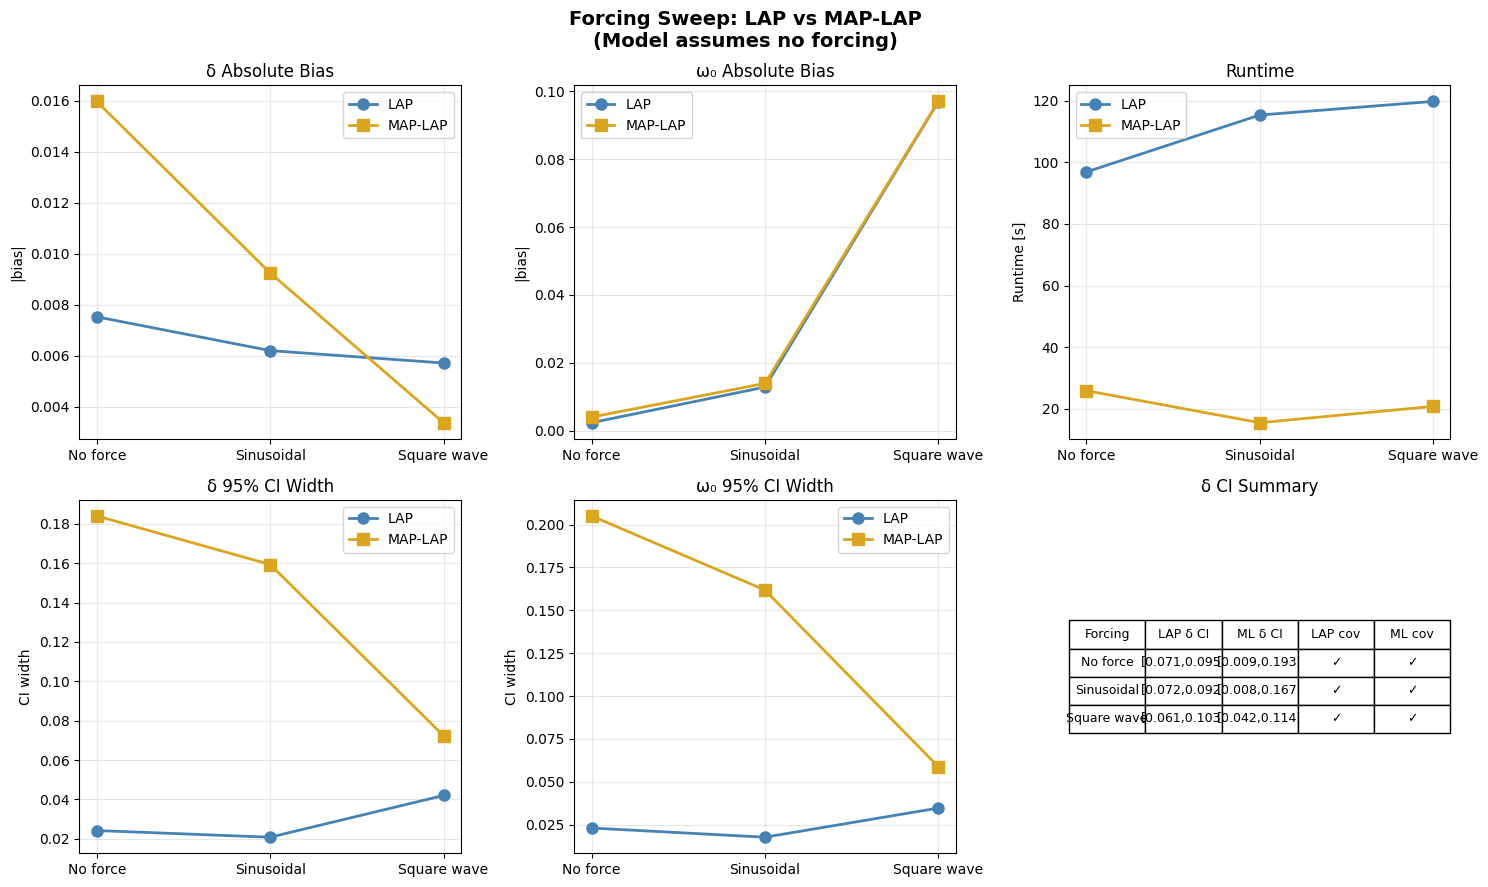

Saved: sweep_forcing.png


In [106]:
fig, axes = pp.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Forcing Sweep: LAP vs MAP-LAP\n(Model assumes no forcing)',
             fontsize=14, fontweight='bold')

x = np.arange(len(forcing_short))

# ── δ bias ──────────────────────────────────────────
axes[0,0].plot(x, lap_d_bias_f, 'o-', color='steelblue', lw=2, ms=8, label='LAP')
axes[0,0].plot(x, ml_d_bias_f,  's-', color='goldenrod', lw=2, ms=8, label='MAP-LAP')
axes[0,0].set_xticks(x); axes[0,0].set_xticklabels(forcing_short)
axes[0,0].set_ylabel('|bias|'); axes[0,0].set_title('δ Absolute Bias')
axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

# ── ω₀ bias ─────────────────────────────────────────
axes[0,1].plot(x, lap_w_bias_f, 'o-', color='steelblue', lw=2, ms=8, label='LAP')
axes[0,1].plot(x, ml_w_bias_f,  's-', color='goldenrod', lw=2, ms=8, label='MAP-LAP')
axes[0,1].set_xticks(x); axes[0,1].set_xticklabels(forcing_short)
axes[0,1].set_ylabel('|bias|'); axes[0,1].set_title('ω₀ Absolute Bias')
axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)

# ── Runtime ──────────────────────────────────────────
axes[0,2].plot(x, lap_rt_f, 'o-', color='steelblue', lw=2, ms=8, label='LAP')
axes[0,2].plot(x, ml_rt_f,  's-', color='goldenrod', lw=2, ms=8, label='MAP-LAP')
axes[0,2].set_xticks(x); axes[0,2].set_xticklabels(forcing_short)
axes[0,2].set_ylabel('Runtime [s]'); axes[0,2].set_title('Runtime')
axes[0,2].legend(); axes[0,2].grid(True, alpha=0.3)

# ── δ CI width ───────────────────────────────────────
axes[1,0].plot(x, lap_d_width_f, 'o-', color='steelblue', lw=2, ms=8, label='LAP')
axes[1,0].plot(x, ml_d_width_f,  's-', color='goldenrod', lw=2, ms=8, label='MAP-LAP')
axes[1,0].set_xticks(x); axes[1,0].set_xticklabels(forcing_short)
axes[1,0].set_ylabel('CI width'); axes[1,0].set_title('δ 95% CI Width')
axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3)

# ── ω₀ CI width ──────────────────────────────────────
axes[1,1].plot(x, lap_w_width_f, 'o-', color='steelblue', lw=2, ms=8, label='LAP')
axes[1,1].plot(x, ml_w_width_f,  's-', color='goldenrod', lw=2, ms=8, label='MAP-LAP')
axes[1,1].set_xticks(x); axes[1,1].set_xticklabels(forcing_short)
axes[1,1].set_ylabel('CI width'); axes[1,1].set_title('ω₀ 95% CI Width')
axes[1,1].legend(); axes[1,1].grid(True, alpha=0.3)

# ── Summary table ────────────────────────────────────
axes[1,2].axis('off')
col_labels = ['Forcing', 'LAP δ CI', 'ML δ CI', 'LAP cov', 'ML cov']
rows = []
for i, forcing in enumerate(forcing_short):
    lap_r = lap_results_f[i]
    ml_r  = map_lap_results_f[i]
    if lap_r['status'] == 'ok' and ml_r['status'] == 'ok':
        rows.append([
            forcing,
            f"[{lap_r['d_ci'][0]:.3f},{lap_r['d_ci'][1]:.3f}]",
            f"[{ml_r['d_ci'][0]:.3f},{ml_r['d_ci'][1]:.3f}]",
            '✓' if lap_r['d_cover'] else '✗',
            '✓' if ml_r['d_cover'] else '✗',
        ])
table = axes[1,2].table(
    cellText=rows, colLabels=col_labels,
    loc='center', cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.5)
axes[1,2].set_title('δ CI Summary')

pp.tight_layout()
pp.savefig('sweep_forcing.png', dpi=200, bbox_inches='tight')
pp.show()
print("Saved: sweep_forcing.png")

In [108]:
import time
import numpy as np
import torch

# Load baseline data
with open(data_dir + 'data_sigma010.pkl', 'rb') as f:
    d = pickle.load(f)

obs     = d['data_sampled_random_with_noise']['No external force']['sparsity 1.667Hz']
t_obs   = obs['t']
y_obs   = obs['x']
n_obs   = len(t_obs)
sigma   = 0.1
R       = sigma ** 2
mu_x1   = y_obs[0]
h       = t_obs[1] - t_obs[0]
m_sub   = compute_m_sub(n_obs, h)

print(f"n_obs={n_obs}  h={h:.4f}  m_sub={m_sub}")

# ── LAP ──────────────────────────────────────────────
print("\nRunning LAP...")
theta0_np = find_theta0_sweep(t_obs, y_obs, n_obs, 1, mu_x1, c, a, b, m_sub)

t_start = time.time()
lap_samples, _ = LAP_parallel(
    t_obs, y_obs, theta0_np,
    n_obs, 1, mu_x1, c, a, b, m_sub, M2=5, n_jobs=-1
)
lap_time = time.time() - t_start

lap_d_mean = np.mean(lap_samples[:, 0])
lap_w_mean = np.mean(lap_samples[:, 1])
lap_d_ci   = np.percentile(lap_samples[:, 0], [2.5, 97.5])
lap_w_ci   = np.percentile(lap_samples[:, 1], [2.5, 97.5])

print(f"\nLAP runtime: {lap_time:.1f}s")
print(f"δ  estimate={lap_d_mean:.4f}  CI=[{lap_d_ci[0]:.4f}, {lap_d_ci[1]:.4f}]  width={lap_d_ci[1]-lap_d_ci[0]:.4f}  cover={lap_d_ci[0]<=delta_true<=lap_d_ci[1]}")
print(f"ω₀ estimate={lap_w_mean:.4f}  CI=[{lap_w_ci[0]:.4f}, {lap_w_ci[1]:.4f}]  width={lap_w_ci[1]-lap_w_ci[0]:.4f}  cover={lap_w_ci[0]<=omega0_true<=lap_w_ci[1]}")

# ── MAP-Laplace ───────────────────────────────────────
print("\nRunning MAP-Laplace...")
t_start = time.time()
ml_samples, ml_theta_map, ml_sigma = run_MAP_LAP(
    t_obs, y_obs, theta_prior, D,
    n_obs, mu_x1, c, R, m_sub
)
ml_time = time.time() - t_start

ml_d_mean = np.mean(ml_samples[:, 0])
ml_w_mean = np.mean(ml_samples[:, 1])
ml_d_ci   = np.percentile(ml_samples[:, 0], [2.5, 97.5])
ml_w_ci   = np.percentile(ml_samples[:, 1], [2.5, 97.5])

print(f"\nMAP-Laplace runtime: {ml_time:.1f}s")
print(f"δ  estimate={ml_d_mean:.4f}  CI=[{ml_d_ci[0]:.4f}, {ml_d_ci[1]:.4f}]  width={ml_d_ci[1]-ml_d_ci[0]:.4f}  cover={ml_d_ci[0]<=delta_true<=ml_d_ci[1]}")
print(f"ω₀ estimate={ml_w_mean:.4f}  CI=[{ml_w_ci[0]:.4f}, {ml_w_ci[1]:.4f}]  width={ml_w_ci[1]-ml_w_ci[0]:.4f}  cover={ml_w_ci[0]<=omega0_true<=ml_w_ci[1]}")

# ── Summary ───────────────────────────────────────────
print("\n── Baseline Table Values ─────────────────────────────────────")
print(f"{'':15s}  {'LAP δ':>10s}  {'LAP ω₀':>10s}  {'ML δ':>10s}  {'ML ω₀':>10s}")
print(f"{'True':15s}  {delta_true:>10.4f}  {omega0_true:>10.4f}  {delta_true:>10.4f}  {omega0_true:>10.4f}")
print(f"{'Estimate':15s}  {lap_d_mean:>10.4f}  {lap_w_mean:>10.4f}  {ml_d_mean:>10.4f}  {ml_w_mean:>10.4f}")
print(f"{'CI low':15s}  {lap_d_ci[0]:>10.4f}  {lap_w_ci[0]:>10.4f}  {ml_d_ci[0]:>10.4f}  {ml_w_ci[0]:>10.4f}")
print(f"{'CI high':15s}  {lap_d_ci[1]:>10.4f}  {lap_w_ci[1]:>10.4f}  {ml_d_ci[1]:>10.4f}  {ml_w_ci[1]:>10.4f}")
print(f"{'CI width':15s}  {lap_d_ci[1]-lap_d_ci[0]:>10.4f}  {lap_w_ci[1]-lap_w_ci[0]:>10.4f}  {ml_d_ci[1]-ml_d_ci[0]:>10.4f}  {ml_w_ci[1]-ml_w_ci[0]:>10.4f}")
print(f"{'True in CI':15s}  {'Yes' if lap_d_ci[0]<=delta_true<=lap_d_ci[1] else 'No':>10s}  {'Yes' if lap_w_ci[0]<=omega0_true<=lap_w_ci[1] else 'No':>10s}  {'Yes' if ml_d_ci[0]<=delta_true<=ml_d_ci[1] else 'No':>10s}  {'Yes' if ml_w_ci[0]<=omega0_true<=ml_w_ci[1] else 'No':>10s}")
print(f"{'Runtime':15s}  {lap_time:>10.1f}s  {'':>10s}  {ml_time:>10.1f}s  {'':>10s}")

n_obs=100  h=0.6010  m_sub=11

Running LAP...
theta0: delta=0.0800  omega0=0.3100
Eigenvalues before fix: [27524.85009381 83530.56398744]
A matrix:
[[-0.00421896 -0.00247111]
 [-0.00430479  0.00242184]]
  dim=0 z=-4.00 theta=(0.0969,0.3272) lp=35.62
  dim=0 z=-2.67 theta=(0.0913,0.3215) lp=37.47
  dim=0 z=-1.33 theta=(0.0856,0.3157) lp=38.54
  dim=0 z=+0.00 theta=(0.0800,0.3100) lp=38.55
  dim=0 z=+1.33 theta=(0.0744,0.3043) lp=37.17
  dim=0 z=+2.67 theta=(0.0687,0.2985) lp=34.18
  dim=0 z=+4.00 theta=(0.0631,0.2928) lp=29.46
  dim=1 z=-4.00 theta=(0.0899,0.3003) lp=30.57
  dim=1 z=-2.67 theta=(0.0866,0.3035) lp=34.43
  dim=1 z=-1.33 theta=(0.0833,0.3068) lp=37.21
  dim=1 z=+0.00 theta=(0.0800,0.3100) lp=38.55
  dim=1 z=+1.33 theta=(0.0767,0.3132) lp=38.17
  dim=1 z=+2.67 theta=(0.0734,0.3165) lp=35.99
  dim=1 z=+4.00 theta=(0.0701,0.3197) lp=32.11
Peak log posterior: 38.55  threshold: 27.05
Coarse scan bounds: z[0]=[-4.00,4.00]  z[1]=[-4.00,4.00]
Evaluating 121 grid points on -1 cores

In [109]:
fig, axes = pp.subplots(3, 3, figsize=(15, 13))
fig.suptitle('Stress Test Sweeps: LAP vs MAP-Laplace', 
             fontsize=14, fontweight='bold')

# ── Row 1: Noise Sweep ───────────────────────────────
sigma_vals = [r['sigma'] for r in lap_results if r['status'] == 'ok']

axes[0,0].plot(sigma_vals, [r['d_bias']  for r in lap_results if r['status'] == 'ok'],
               'o-', color='steelblue', lw=2, ms=6, label='LAP')
axes[0,0].plot(sigma_vals, [r['d_bias']  for r in map_lap_results if r['status'] == 'ok'],
               's-', color='goldenrod', lw=2, ms=6, label='MAP-Laplace')
axes[0,0].set_xlabel('σ'); axes[0,0].set_ylabel('|bias|')
axes[0,0].set_title('Noise: δ Bias'); axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(sigma_vals, [r['d_width'] for r in lap_results if r['status'] == 'ok'],
               'o-', color='steelblue', lw=2, ms=6, label='LAP')
axes[0,1].plot(sigma_vals, [r['d_width'] for r in map_lap_results if r['status'] == 'ok'],
               's-', color='goldenrod', lw=2, ms=6, label='MAP-Laplace')
axes[0,1].set_xlabel('σ'); axes[0,1].set_ylabel('CI width')
axes[0,1].set_title('Noise: δ CI Width'); axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)

axes[0,2].plot(sigma_vals, [int(r['d_cover']) for r in lap_results if r['status'] == 'ok'],
               'o-', color='steelblue', lw=2, ms=6, label='LAP')
axes[0,2].plot(sigma_vals, [int(r['d_cover']) for r in map_lap_results if r['status'] == 'ok'],
               's-', color='goldenrod', lw=2, ms=6, label='MAP-Laplace')
axes[0,2].set_xlabel('σ'); axes[0,2].set_ylabel('True in CI')
axes[0,2].set_title('Noise: Coverage')
axes[0,2].set_yticks([0,1]); axes[0,2].set_yticklabels(['No','Yes'])
axes[0,2].legend(); axes[0,2].grid(True, alpha=0.3)

# ── Row 2: Sparsity Sweep ────────────────────────────
n_vals = [r['n_obs'] for r in lap_results_n if r['status'] == 'ok']

axes[1,0].plot(n_vals, [r['d_bias']  for r in lap_results_n if r['status'] == 'ok'],
               'o-', color='steelblue', lw=2, ms=6, label='LAP')
axes[1,0].plot(n_vals, [r['d_bias']  for r in map_lap_results_n if r['status'] == 'ok'],
               's-', color='goldenrod', lw=2, ms=6, label='MAP-Laplace')
axes[1,0].set_xlabel('n observations'); axes[1,0].set_ylabel('|bias|')
axes[1,0].set_title('Sparsity: δ Bias'); axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(n_vals, [r['d_width'] for r in lap_results_n if r['status'] == 'ok'],
               'o-', color='steelblue', lw=2, ms=6, label='LAP')
axes[1,1].plot(n_vals, [r['d_width'] for r in map_lap_results_n if r['status'] == 'ok'],
               's-', color='goldenrod', lw=2, ms=6, label='MAP-Laplace')
axes[1,1].set_xlabel('n observations'); axes[1,1].set_ylabel('CI width')
axes[1,1].set_title('Sparsity: δ CI Width'); axes[1,1].legend(); axes[1,1].grid(True, alpha=0.3)

axes[1,2].plot(n_vals, [int(r['d_cover']) for r in lap_results_n if r['status'] == 'ok'],
               'o-', color='steelblue', lw=2, ms=6, label='LAP')
axes[1,2].plot(n_vals, [int(r['d_cover']) for r in map_lap_results_n if r['status'] == 'ok'],
               's-', color='goldenrod', lw=2, ms=6, label='MAP-Laplace')
axes[1,2].set_xlabel('n observations'); axes[1,2].set_ylabel('True in CI')
axes[1,2].set_title('Sparsity: Coverage')
axes[1,2].set_yticks([0,1]); axes[1,2].set_yticklabels(['No','Yes'])
axes[1,2].legend(); axes[1,2].grid(True, alpha=0.3)

# ── Row 3: Forcing Sweep ─────────────────────────────
forcing_short = ['No force', 'Sinusoidal', 'Square wave']
x = np.arange(len(forcing_short))

axes[2,0].plot(x, [r['d_bias']  for r in lap_results_f if r['status'] == 'ok'],
               'o-', color='steelblue', lw=2, ms=6, label='LAP')
axes[2,0].plot(x, [r['d_bias']  for r in map_lap_results_f if r['status'] == 'ok'],
               's-', color='goldenrod', lw=2, ms=6, label='MAP-Laplace')
axes[2,0].set_xticks(x); axes[2,0].set_xticklabels(forcing_short)
axes[2,0].set_ylabel('|bias|')
axes[2,0].set_title('Forcing: δ Bias'); axes[2,0].legend(); axes[2,0].grid(True, alpha=0.3)

axes[2,1].plot(x, [r['d_width'] for r in lap_results_f if r['status'] == 'ok'],
               'o-', color='steelblue', lw=2, ms=6, label='LAP')
axes[2,1].plot(x, [r['d_width'] for r in map_lap_results_f if r['status'] == 'ok'],
               's-', color='goldenrod', lw=2, ms=6, label='MAP-Laplace')
axes[2,1].set_xticks(x); axes[2,1].set_xticklabels(forcing_short)
axes[2,1].set_ylabel('CI width')
axes[2,1].set_title('Forcing: δ CI Width'); axes[2,1].legend(); axes[2,1].grid(True, alpha=0.3)

axes[2,2].plot(x, [int(r['d_cover']) for r in lap_results_f if r['status'] == 'ok'],
               'o-', color='steelblue', lw=2, ms=6, label='LAP')
axes[2,2].plot(x, [int(r['d_cover']) for r in map_lap_results_f if r['status'] == 'ok'],
               's-', color='goldenrod', lw=2, ms=6, label='MAP-Laplace')
axes[2,2].set_xticks(x); axes[2,2].set_xticklabels(forcing_short)
axes[2,2].set_ylabel('True in CI')
axes[2,2].set_title('Forcing: Coverage')
axes[2,2].set_yticks([0,1]); axes[2,2].set_yticklabels(['No','Yes'])
axes[2,2].legend(); axes[2,2].grid(True, alpha=0.3)

pp.tight_layout()
pp.savefig('sweep_combined.png', dpi=200, bbox_inches='tight')
pp.show()
print("Saved: sweep_combined.png")